In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from metpy.plots import SkewT, Hodograph
import conf
conf = conf.conf
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

In [2]:
def modify_input_sounding(my_file, out_file, conf):
    # Read input sounding.
    input_sounding = read_input_sounding(my_file)

    ########################################################################
    # Modify the input sounding wind profile.
    ########################################################################
    if conf['modify_wind_profile'] :
      input_sounding['u'][:] = 0.0 #Overwrite the original wind profile
      input_sounding['v'][:] = 0.0

      if conf['shear_type'] == 'Linear' :
         #Linear shear component - U wind
         max_u = conf['shear_depth_u'] * conf['shear_strength_u']
         input_sounding['u'] = input_sounding['height'] * conf['shear_strength_u']
         input_sounding['u'][ input_sounding['height'] > conf['shear_depth_u'] ] = max_u
         #Linear shear component - V wind
         max_u = conf['shear_depth_v'] * conf['shear_strength_v']
         input_sounding['v'] = input_sounding['height'] * conf['shear_strength_v']
         input_sounding['v'][ input_sounding['height'] > conf['shear_depth_v'] ] = max_v

      if conf['shear_type'] == 'Curved' :
         #Maximum turning in wind direction (is a function of how much shear is explained by the curved part of the hodograph)
         #The maximum turning is pi (half a circle), if half the shear is associated with the curved part then a quarter circle hodograph is obtained.
         curved_shear_theta = conf['curved_shear_per'] * np.pi
         #Curved hodograp up to certain level, then linear shear.

         #Curved hodograp part
         if conf['curved_shear_per'] > 0.0 :
            curved_int_shear =  conf['int_total_shear'] * conf['curved_shear_per']
            curved_dep_shear =  conf['total_shear_depth'] * conf['curved_shear_per']
            curved_amp_shear =  curved_int_shear / curved_shear_theta
 
            mask = input_sounding['height'] <=  curved_dep_shear
            input_sounding['v'][mask] = -1.0 * curved_amp_shear * np.sin( (input_sounding['height'][mask] / curved_dep_shear )* curved_shear_theta )
            input_sounding['u'][mask] = -1.0 * curved_amp_shear * np.cos( (input_sounding['height'][mask] / curved_dep_shear )* curved_shear_theta )
         else :
            curved_amp_shear = 0.0

         #Linear shear part 
         u_ini = -1.0 * curved_amp_shear * np.cos( curved_shear_theta )  #U and V wind components at the base of the linear shear layer.
         v_ini = -1.0 * curved_amp_shear * np.sin( curved_shear_theta )

         linear_int_shear = conf['int_total_shear'] * (1.0 - conf['curved_shear_per'])

         u_fin = u_ini + linear_int_shear * np.sin( curved_shear_theta )
         v_fin = v_ini - linear_int_shear * np.cos( curved_shear_theta )

         mask = ( input_sounding['height'] >  curved_dep_shear ) & ( input_sounding['height'] <= conf['total_shear_depth'] )
         input_sounding['v'][mask] = v_ini + ( v_fin - v_ini) * ( input_sounding['height'][mask] - curved_dep_shear ) / ( conf['total_shear_depth'] - curved_dep_shear ) 
         input_sounding['u'][mask] = u_ini + ( u_fin - u_ini) * ( input_sounding['height'][mask] - curved_dep_shear ) / ( conf['total_shear_depth'] - curved_dep_shear )

         #Constant wind part.
         mask = input_sounding['height'] >=  conf['total_shear_depth']
         input_sounding['v'][mask] = v_fin
         input_sounding['u'][mask] = u_fin
		 
         linear_amp_shear = curved_int_shear / curved_shear_theta

      #print( input_sounding['u'] , input_sounding['v'] ) 


      #Low level jet component 
      input_sounding['u'] = input_sounding['u'] - conf['llj_amp'] * np.exp( -0.5 * ( conf['llj_h'] - input_sounding['height'] )**2 / conf['llj_width']**2  ) * np.sin( np.deg2rad(conf['llj_dir']) )
      input_sounding['v'] = input_sounding['v'] - conf['llj_amp'] * np.exp( -0.5 * ( conf['llj_h'] - input_sounding['height'] )**2 / conf['llj_width']**2  ) * np.cos( np.deg2rad(conf['llj_dir']) )

      #Add the surface wind speed to the entire profile.
      input_sounding['u'] = input_sounding['u'] + conf['surf_u']
      input_sounding['v'] = input_sounding['v'] + conf['surf_v']

      if conf['remove_mean_wind']:
          # Remove 0-6 km mean wind (this will keep the convection near the center of the
          # domain for a longer time)
          mask = input_sounding['height'] < 6000.0
          mean_u = np.mean(input_sounding['u'][mask])
          mean_v = np.mean(input_sounding['v'][mask])
          input_sounding['u'] = input_sounding['u'] - mean_u
          input_sounding['v'] = input_sounding['v'] - mean_v


    ########################################################################
    # Modify the input sounding theta profile.
    ########################################################################
    if conf['modify_theta_profile']:
        input_sounding['theta'][:] = 0.0
        input_sounding['surf_theta'] = conf['surf_theta']
        input_sounding['theta'][0] = conf['surf_theta']

        index = np.zeros(len(input_sounding['height'])).astype(int)
        for ii in range(len(conf['theta_layer_limits'])):
            mask = input_sounding['height'] >= conf['theta_layer_limits'][ii]
            index[mask] = index[mask] + 1
        index = index - 1
        delta_theta = conf['dthetadz_layer'][index]

        input_sounding['theta'][1:] = conf['surf_theta'] + np.cumsum(
            delta_theta[1:] * (input_sounding['height'][1:] - input_sounding['height'][:-1]))

    ########################################################################
    # Modify stability
    ########################################################################
    if conf['modify_stability']  :
       #factor increases linearly with height. So multiplying factor * temperature can
       #increase or decrease the stability. 
       #factor = 1.0 + 0.01 * conf['stability_factor'] *  input_sounding['height'] / ( 10000.0 ) 
       factor = np.sin( input_sounding['height'] * np.pi / (2*conf['stability_factor_height']) ) 
       factor[ factor < 0.0 ] = 0.0                                                           
       factor[ input_sounding['height'] > 2*conf['stability_factor_height'] ] = 0.0
       factor = 1.0 + 0.01 * conf['stability_factor'] * factor
       input_sounding['theta'] = factor * input_sounding['theta'] 

    ########################################################################
    # Modify the input sounding moisture profile.
    ########################################################################
    if conf['modify_moisture_profile']:
       if conf['dry_run']:
          input_sounding['qv'][:] = 0.0  # Dry simulation.
        
       #Multiplicative increase/decrease of low level moisture
       tmp_z = (-input_sounding['height'] + conf['low_level_moisture_height'])/250.0
       tmp_factor = 1.0 + 0.01 * conf['low_level_moisture_mult_factor'] / ( 1.0 + np.exp( -tmp_z ) )
       input_sounding['qv'] = input_sounding['qv'] * tmp_factor

       #Multiplicative increase/decrease of mid-upper level moisture.
       tmp_z = ( input_sounding['height'] - conf['mid_level_moisture_height'])/250.0
       tmp_factor = 1.0 + 0.01 * conf['mid_level_moisture_mult_factor'] / ( 1.0 + np.exp( -tmp_z ) )
       input_sounding['qv'] = input_sounding['qv'] * tmp_factor

    ########################################################################
    # Check saturation
    ########################################################################
       
    epsilon = 0.622
    es = 6.112 * np.exp( 17.67 * ( input_sounding['t'] - 273.16 ) / ( input_sounding['t'] - 273.16 + 243.5 ) )                #[in hPa]
    input_sounding['qvs'] = es * epsilon / ( input_sounding['p'] - ( 1 - epsilon ) * es ) * 1000.0                            #[in g/kg]
    input_sounding['qv'][input_sounding['qv'] > input_sounding['qvs'] ] = input_sounding['qvs'][input_sounding['qv'] > input_sounding['qvs'] ]   #[remove qv values over saturation]


    # Write input_sounding
    #return input_sounding
    write_input_sounding(out_file, input_sounding)


def read_input_sounding(my_file):

    cp=1004.0
    Rd=287.0
    g=9.8
    P0=100000.0
    input_sounding = dict()
    # Read input_sounding
    with open(my_file) as f:
        lines = f.readlines()
    lines = [line[:-1] for line in lines]  # Remove the new line character
    line_split = lines[0].split()
    input_sounding['surf_pressure'] = float(line_split[0])
    input_sounding['surf_theta'] = float(line_split[1])
    input_sounding['surf_qv'] = float(line_split[2])
    input_sounding['nlevs'] = len(lines) - 1
    input_sounding['height'] = np.zeros(input_sounding['nlevs'])
    input_sounding['theta'] = np.zeros(input_sounding['nlevs'])
    input_sounding['qv'] = np.zeros(input_sounding['nlevs'])
    input_sounding['u'] = np.zeros(input_sounding['nlevs'])
    input_sounding['v'] = np.zeros(input_sounding['nlevs'])
    input_sounding['p'] = np.zeros(input_sounding['nlevs'])
   
    tmp_press = np.zeros( input_sounding['nlevs'] )
    
    tmp_press[0] = (input_sounding['surf_pressure']*100) ** ( Rd/cp )

    for ii in range(input_sounding['nlevs']):
        line_split = lines[ii + 1].split()
        input_sounding['height'][ii] = float(line_split[0])
        input_sounding['theta'][ii] = float(line_split[1])
        input_sounding['qv'][ii] = float(line_split[2])
        input_sounding['u'][ii] = float(line_split[3])
        input_sounding['v'][ii] = float(line_split[4])

        if ( ii >= 1 ) :
           theta_mean = 0.5 * ( input_sounding['theta'][ii] + input_sounding['theta'][ii-1] )
           dz         = input_sounding['height'][ii] - input_sounding['height'][ii-1]
           tmp_press[ii] = tmp_press[ii-1] - g * ( P0 ** ( Rd/cp ) ) * ( dz ) / ( cp * theta_mean )
    input_sounding['p'] = tmp_press ** ( ( cp / Rd ) ) / 100.0
    input_sounding['t'] = input_sounding['theta'] * tmp_press / ( P0 ** ( Rd/cp ) ) 

    return input_sounding


def write_input_sounding(my_file, input_sounding):
    with open(my_file, 'w') as f:
        f.write(str(input_sounding['surf_pressure']) + ' ' + str(input_sounding['surf_theta']) + ' ' + str(
            input_sounding['surf_qv']))
        f.write('\n')
        for ii in range(input_sounding['nlevs']):
            f.write(str(input_sounding['height'][ii]) + ' ' + str(input_sounding['theta'][ii]) + ' ' + str(
                input_sounding['qv'][ii]) + ' ' + str(input_sounding['u'][ii]) + ' ' + str(input_sounding['v'][ii]))
            f.write('\n')

/tmp/ipykernel_929237/369507279.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("gist_rainbow")


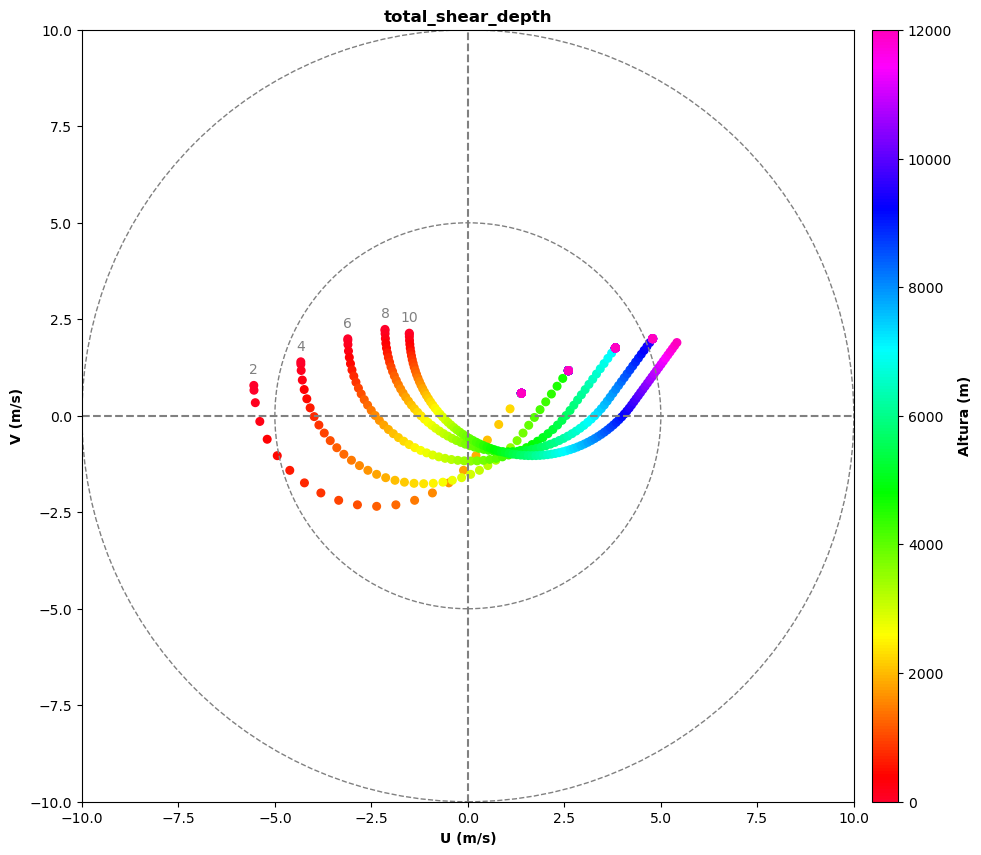

In [24]:
input_sounding_path_orig = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding" #sondeo base/original
input_sounding_path_mod = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding_mod" #sondeo modificado


conf['modify_wind_profile'] = True
conf['remove_mean_wind']    = True
conf['shear_type']          = 'Curved'
#conf['total_shear_depth']  = 6000   #Depth of circular shear. (tipical range [4000 , 8000]) 
conf['int_total_shear']    = 10    #Total integrated shear (in m/s, tacking curvature into account) (tipical range [0 , 30])
conf['curved_shear_per']   = 0.8 #Which proportion of the total shear depth will be curved. (tipical range [0 , 1]) 

#Hodografa
fig, ax = plt.subplots(figsize=(12, 12))

h = Hodograph(ax, component_range=10)
h.add_grid(increment=5)

rango = np.arange(2000,12000,2000)
# markers = ('o', 's', "^", "_","|")
# Definimos un colormap 
cmap = cm.get_cmap("gist_rainbow") 
norm = mcolors.Normalize(vmin= 0, vmax=12000)

legend_elements = []

for i, par in enumerate(rango):

    conf['total_shear_depth'] = par

    modify_input_sounding(input_sounding_path_orig,input_sounding_path_mod, conf)
    sounding = read_input_sounding(input_sounding_path_mod)

    z=sounding['height'] * units.meter
    u=sounding['u'] * units.meter / units.second
    v=sounding['v'] * units.meter / units.second
    z_km = z.to('km')
    idx = np.argmin(np.abs(z_km.m - 10)) #index for 10km

    # Elegir un color distinto para cada hodógrafa
    #color = cmap(norm(par))
    
    # legend_elements.append(Line2D([0], [0], marker=markers[i], color='k', 
    #                             linestyle='None', markersize=10,
    #                             label=f'{par} m'))

    # Graficar la trayectoria de la hodógrafa con colores según la altura
    #ax.plot(u,v,color=color)
    ax.scatter(u[0:idx+1].m, v[0:idx+1].m, c=z_km[0:idx+1].m, cmap=cmap, s=30)

    
    # Agregar número del parámetro en el punto inicial de la hodógrafa
    ax.text(u[0].m, v[0].m + 0.3,   # un pequeño desplazamiento en y
            f"{int(par/1000)}", 
            fontsize=10, ha="center", color="gray")

    ax.set_xlabel('U (m/s)', fontsize=10, weight = 'bold')  # Título para el eje X
    ax.set_ylabel('V (m/s)', fontsize=10, weight = 'bold')  # Título para el eje Y

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", pad=0.02, shrink = 0.835, aspect = 30)
cbar.set_label("Altura (m)", fontsize=10, weight='bold')


# leg = ax.legend(handles=legend_elements, title="total_shear_depth (m)", 
#           loc="upper right", fontsize=10, title_fontsize=10)
# leg.get_title().set_fontweight('bold')

ax.set_title('total_shear_depth', weight = 'bold', fontsize = 12)

plt.savefig('/home/esteban.semino/datosmunin3/figs/parameters/total_shear_depth_3.png',  bbox_inches="tight", dpi=300)


/tmp/ipykernel_884371/3100685602.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_orig = cm.get_cmap("Reds")


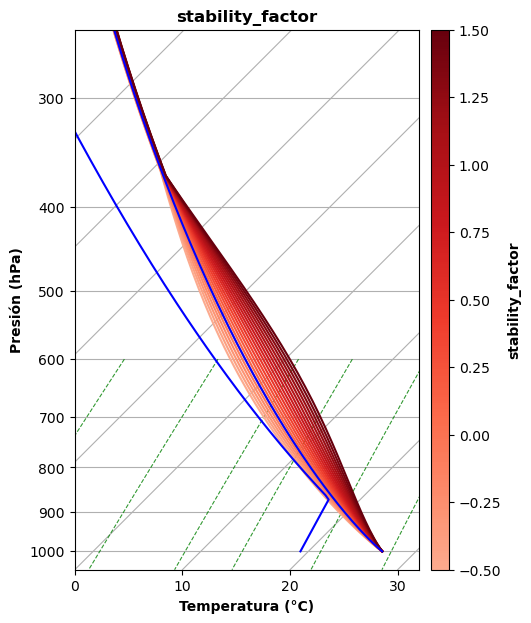

In [36]:
input_sounding_path_orig = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding" #sondeo base/original
input_sounding_path_mod = "/home/jorge.gacitua/datosmunin/em_quarter_ss/input_sounding_mod" #sondeo modificado

#Parameters controling the stability (temperature profile)
conf['modify_stability'] = True          #Are we going to modify the original stability?
#conf['stability_factor'] = 1.5     #Factor controling the stability change (tipical range [-1.5 , 1.5] )
conf['stability_factor_height'] = 4000 #2500+(param4*(10000-2500)) #Height of maximum warming / cooling. (tipical range [2500 , 10000 ] )

#Parameters controling the shape of the moisture profile.
conf['modify_moisture_profile'] = False    #Are we going to modify the original moisture profile?
conf['dry_run']                 = False       #Assume 0.0 moisture content at all levels?
conf['low_level_moisture_height'] = 2000    #Low level moisture modification will take effect below this level.
#conf['low_level_moisture_mult_factor'] = 0 #Moisture modification for low levels (tipical range [-15.0 , 15.0] )   
conf['mid_level_moisture_height'] = 2000   #Mid level moisture modification will take effect above this level.
conf['mid_level_moisture_mult_factor'] = 0  #Moisture modification factor for mid levels (tipical range [-10.0 , 10.0 ] )

fig = plt.figure(figsize=(12, 6))

# Definimos un colormap 
# recortar el colormap original (usar solo la parte 0.3→1.0 de "Greens")
cmap_orig = cm.get_cmap("Reds")
cmap = mcolors.LinearSegmentedColormap.from_list(
    "Reds_trunc", cmap_orig(np.linspace(0.3, 1, 256))
)

rango = np.arange(-0.5,1.6,0.1)

# normalización acorde a tu rango
norm = mcolors.Normalize(vmin=rango.min(), vmax=rango.max())

# Grid for plots
skew = SkewT(fig, rotation=45, rect=(0.05,0.05,0.50,0.90))

for i, par in enumerate(rango):

    conf['stability_factor'] = par

    modify_input_sounding(input_sounding_path_orig,input_sounding_path_mod, conf)
    sounding = read_input_sounding(input_sounding_path_mod)

    p=sounding['p'] * units.hPa
    t=sounding['t'] * units.kelvin
    t = t.to('degC')
    z=sounding['height'] * units.meter
    # u=sounding['u'] * units.meter / units.second
    # v=sounding['v'] * units.meter / units.second
    qv = sounding['qv'] / 1000 * units('kg/kg')
    td = mpcalc.dewpoint_from_specific_humidity(p,qv)
    # Plot the data using normal plotting functions, in this case using
    # log scaling in Y, as dictated by the typical meteorological plot

    color = cmap(norm(par))
    
    skew.plot(p , t , color = color) [0]
    #skew.plot(p , td , color = color) [0]

    # Calculate full parcel profile and add to plot as black line
    # prof = mpcalc.parcel_profile(p , t[0] , td[0] ).to('degC')
    # prof_line = skew.plot(p, prof, 'k', linewidth=2) [0]

conf['modify_stability'] = False 

modify_input_sounding(input_sounding_path_orig,input_sounding_path_mod, conf)
sounding = read_input_sounding(input_sounding_path_mod)

p=sounding['p'] * units.hPa
t=sounding['t'] * units.kelvin
t = t.to('degC')
z=sounding['height'] * units.meter
# u=sounding['u'] * units.meter / units.second
# v=sounding['v'] * units.meter / units.second
qv = sounding['qv'] / 1000 * units('kg/kg')
td = mpcalc.dewpoint_from_specific_humidity(p,qv)

skew.plot(p , t , color = 'blue') [0]
skew.plot(p , td , 'blue') [0]

#add labels
skew.ax.set_xlabel('Temperatura (°C)',weight='bold')
skew.ax.set_ylabel('Presión (hPa)',weight='bold')

# Set the limits of the plot
skew.ax.set_xlim(0, 32)
skew.ax.set_ylim(1050, 250)

# Add the relevant special lines
# skew.plot_dry_adiabats(linewidths=0.8)
# skew.plot_moist_adiabats(linewidths=0.8)
skew.plot_mixing_lines(linewidths=0.8)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm,ax = skew.ax ,orientation="vertical", pad=0.02, shrink = 1, aspect = 30)
cbar.set_label("stability_factor", fontsize=10, weight='bold')

skew.ax.set_title('stability_factor', weight = 'bold', fontsize = 12)

plt.savefig('/home/esteban.semino/datosmunin3/figs/parameters/stability_factor.png', bbox_inches="tight", dpi=300)